# Bearing Fault Diagnosis from Vibration Data (UORED-VAFCLS)

<p align="right">
Run Time: under a minute on a GPU (training adds about a minute; the segment-split comparison always trains one small model)
</p>

This notebook walks through the complete pipeline to train, quantize and convert a
bearing fault detector for Akida 1 hardware, from one second of raw 42 kHz
accelerometer data.

Like the accompanying [README](README.md), it makes two points:

1. **How to bring a single-channel time-series model to Akida 1.** The waveform is
   framed into a 2D tensor and run through an ordinary convolutional network.
2. **How the data is split decides the score.** On bearing-fault datasets, the
   obvious ways of dividing train and test data leak, and they produce
   near-perfect numbers that say little about diagnosing a bearing the model has
   never seen. The README section
   [The Problem of Realistic Evaluation](README.md#the-problem-of-realistic-evaluation-of-bearing-fault-diagnosis-models)
   works through this in full; this notebook shows it happening.

None of the second point is specific to Akida. It is here because a model that
looks excellent for the wrong reasons is a poor starting point for any deployment.

## The Pipeline

The pipeline follows the standard Akida 1 workflow, on one bearing-disjoint fold:
1. Train a float model
2. Post-training quantization (PTQ)
3. Quantization-aware training (QAT) fine-tuning
4. Conversion to Akida `.fbz` format
5. Evaluation of the converted model

It then trains the same model on a leaky split for comparison, and finishes with
the cross-validation results that the reported numbers come from.

Hardware benchmarking is covered separately, in
[uored_vafcls_notebook_benchmark.ipynb](uored_vafcls_notebook_benchmark.ipynb).

In [1]:
# Colab-only setup. Local users: ignore this cell — it does nothing for you.
import sys, os

if 'google.colab' in sys.modules:
    if not os.path.exists('colab_setup.py'):
        !wget -q https://raw.githubusercontent.com/Brainchip-Inc/brainchip_devhub/main/akida1/model_zoo/uored_vafcls/colab_setup.py
    import colab_setup; colab_setup.setup()

In [2]:
import json
import os

import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm import tqdm

# Must be called before any TF ops to make GPU ops deterministic.
tf.config.experimental.enable_op_determinism()

import cnn2snn
from cnn2snn import AkidaVersion, load_quantized_model, set_akida_version

DATA_PATH = './data/uored_vafcls'
MODELS_DIR = './models/'
os.makedirs(MODELS_DIR, exist_ok=True)

# False loads the pretrained fold-42 models from pretrained_models/, which the
# README tables describe. True retrains them (about a minute on a GPU).
RUN_FLOAT_TRAINING = False
RUN_QAT_TRAINING = False

# Trains the same model on the leaky segment-level split, for comparison.
# There is no pretrained model for that split; set False to use the numbers
# stored in docs/metrics.json instead.
RUN_SEGMENT_COMPARISON = True

SEED = 0

## Dataset

**UORED-VAFCLS** holds 60 accelerometer recordings, each 10 s at 42 kHz, from 20
physical bearings. Every bearing contributes three recordings: one healthy, plus two
severities of a single fault mode.

The four fault modes (inner race, outer race, ball, cage) are **independent labels**,
not classes, and a healthy bearing is the all-zero label vector rather than a fifth
class. The metric is therefore **macro AUROC** over the four labels, which needs no
decision threshold.

### The split is the experiment

In this dataset the fault mode is a property of the bearing: bearings 1–5 carry
inner-race faults, 6–10 outer, 11–15 ball, 16–20 cage. So any split that puts data
from one bearing on both sides of the train/test boundary hands the model a shortcut:
it can recognise *the bearing* (its noise floor, its mounting resonances) and read the
label off that, without learning anything about faults. There are two common ways to
fall into this:

- **Segment-wise splits** cut each recording in time, so the same recording sits on
  both sides.
- **Condition-wise splits** hold out a load or speed setting but keep the same bearings.

This example follows the bearing-disjoint protocol of
[Vieira et al. (2026)](https://arxiv.org/abs/2509.22267): a fold trains on 12 bearings
and tests on the other 8, and no bearing ever appears on both sides. The pretrained
models use **fold 42**, chosen because its score sits close to the cross-validation
mean (more on that at the end).

There is deliberately no validation split: with 36 training recordings, carving one
out would cost a sixth of the data and would itself have to be bearing-disjoint. The
recipe uses a fixed number of epochs, so nothing would consume it.

> **First run:** the prepared dataset (~100 MB) downloads automatically from the
> BrainChip data mirror. See the README's [Dataset](README.md#dataset) section for its
> provenance and licence (CC BY 4.0).

In [3]:
from uored_vafcls_data import (BATCH_SIZE, FIXED_FOLD, INPUT_SHAPE, LABEL_COLUMNS,
                               get_data, get_samples)

FOLD = FIXED_FOLD
train_ds, test_ds = get_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE, fold=FOLD, seed=SEED)
print(f'\nInput shape: {INPUT_SHAPE}, labels: {LABEL_COLUMNS}')

Fold 42: holding out bearings [1, 2, 8, 9, 11, 12, 17, 18]
Train: 36 recordings from 12 bearings [3, 4, 5, 6, 7, 10, 13, 14, 15, 16, 19, 20] (Ball 6, Cage 6, Healthy 12, Inner 6, Outer 6)
Held out: 24 recordings from 8 bearings [1, 2, 8, 9, 11, 12, 17, 18] (Ball 4, Cage 4, Healthy 8, Inner 4, Outer 4)
Train and held out share 0 of 20 bearings -> leakage-free



Input shape: (300, 140, 1), labels: ('inner', 'outer', 'ball', 'cage')


## From waveform to model input

The model sees one second of signal: a 42,000-sample window. Two steps turn it into
something an Akida 1 convolutional network can consume:

1. **uint8 encoding.** Akida takes 8-bit inputs. The signal is offset by +128,
   rounded and clipped to [0, 255]. A single fixed range for the whole dataset
   (rather than per-recording normalisation) keeps the quiet healthy recordings
   from being flattened. The cost is clipping: the loudest recordings, and those
   whose signal sits well away from zero (a few carry a large DC offset), lose part
   of their waveform at the rails, as the cage example below shows.
2. **Framing.** The window is reshaped to **300 × 140 × 1**: 300 frames of 140
   consecutive samples. This is a plain reshape, not a spectrogram. Rows are coarse
   time (one frame every 3.3 ms), columns are fine phase within a frame. It happens in
   the data pipeline rather than the model because an Akida graph cannot contain a
   reshape.

Why 300 × 140 and not 140 × 300? Akida 1's input convolution layer, the only layer
that accepts 8-bit inputs, limits its second input dimension to 256, so the long axis
has to come first. The [model module](uored_vafcls_model.py) docstring lists the other
hardware constraints that fixed the geometry.

Below, one held-out window per condition: the waveform, and the framed tensor the
network actually receives.

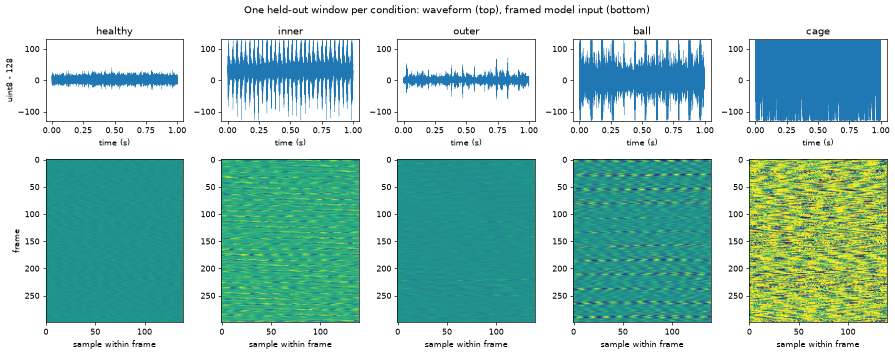

In [4]:
import matplotlib.pyplot as plt

# One held-out window per condition: healthy (all-zero labels) and each fault mode.
wanted = {'healthy': None, **{name: None for name in LABEL_COLUMNS}}
for x_batch, y_batch in test_ds:
    for x, y in zip(x_batch.numpy(), y_batch.numpy()):
        name = 'healthy' if not y.any() else LABEL_COLUMNS[int(np.argmax(y))]
        if wanted[name] is None:
            wanted[name] = x
    if all(v is not None for v in wanted.values()):
        break

# Modest dpi: dense 1 s waveforms make large images otherwise.
fig, axes = plt.subplots(2, len(wanted), figsize=(15, 6), dpi=60,
                         gridspec_kw={'height_ratios': [1, 2]})
for col, (name, x) in enumerate(wanted.items()):
    waveform = x.astype(np.int16).ravel() - 128
    axes[0, col].plot(np.arange(waveform.size) / 42_000, waveform, linewidth=0.3)
    axes[0, col].set_title(name)
    axes[0, col].set_ylim(-130, 130)
    axes[0, col].set_xlabel('time (s)')
    axes[1, col].imshow(x.squeeze(), cmap='viridis', aspect='auto', vmin=0, vmax=255)
    axes[1, col].set_xlabel('sample within frame')
axes[0, 0].set_ylabel('uint8 - 128')
axes[1, 0].set_ylabel('frame')
fig.suptitle('One held-out window per condition: waveform (top), framed model input (bottom)')
fig.tight_layout()
plt.show()

## Model

A 2D convolutional network descended from WDCNN, rebuilt so that every layer maps to
Akida 1. The 7 × 7 stem correlates 7 consecutive samples across 7 consecutive frames.

**Input scaling is part of the model.** A `Rescaling` layer maps the uint8 input to
roughly [-1, 1]. Keeping it in the graph means float training, quantized training and
Akida inference all see identical values, and `cnn2snn` folds it into the first
convolution at conversion time, so it costs nothing on hardware.

In [5]:
from uored_vafcls_model import build_uored_vafcls_model

model = build_uored_vafcls_model(seed=SEED)
model.summary()

Model: "akdcnn_uored_vafcls"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 300, 140, 1)]     0         
                                                                 
 rescaling (Rescaling)       (None, 300, 140, 1)       0         
                                                                 
 stem_conv (Conv2D)          (None, 294, 134, 16)      784       
                                                                 
 stem_bn (BatchNormalizatio  (None, 294, 134, 16)      64        
 n)                                                              
                                                                 
 stem_relu (ReLU)            (None, 294, 134, 16)      0         
                                                                 
 stem_pool (MaxPooling2D)    (None, 147, 67, 16)       0         
                                               

## Float Training

The recipe: 30 epochs of Adam with binary cross-entropy (`from_logits=True`, one
independent output per fault label), batch size 120 (exactly 6 steps over the 720
training windows), and a cosine learning-rate schedule with a 5% warm-up to a peak of
2e-4.

The training windows are random 1 s crops, re-drawn every epoch, with a random gain
applied as augmentation. All hyperparameters were tuned on folds 0–4 only; the
protocol reserves folds 5–104 for evaluation.

Set `RUN_FLOAT_TRAINING = True` in the config cell to retrain instead of loading the
pretrained weights.

In [6]:
from uored_vafcls_train import train_uored_vafcls

float_model_name = 'akdcnn_uored_vafcls.h5'

if RUN_FLOAT_TRAINING:
    train_uored_vafcls(model, train_ds, epochs=30, learning_rate=2e-4, seed=SEED)
    model.save(MODELS_DIR + float_model_name, include_optimizer=False)
    print(f'Float model saved to {MODELS_DIR + float_model_name}')
else:
    print('Loading the pretrained model.')
    model = load_quantized_model('pretrained_models/' + float_model_name)

Loading the pretrained model.


### Reading the results

AUROC measures how well a model *ranks* positive examples above negative ones, so it
needs no decision threshold: 1.0 is perfect separation, 0.5 is chance. It is computed
per fault label and averaged (macro AUROC).

The helpers come from [uored_vafcls_eval.py](uored_vafcls_eval.py), so the notebook and
the scripts compute exactly the same numbers. They are used unchanged at every stage
of the pipeline: float, PTQ, QAT and Akida.

In [7]:
from uored_vafcls_eval import auroc_scores, predict_keras_model, report

float_scores = auroc_scores(*predict_keras_model(model, test_ds))
report(float_scores, f'Float model, fold {FOLD} held-out')


Float model, fold 42 held-out macro AUROC: 0.9119
Per-label AUROC:
  inner  0.9356
  outer  0.9954
  ball   0.9960
  cage   0.7205


## Quantization

Post-training quantization (PTQ) via `cnn2snn.quantize`:

- **Input**: 8-bit (`input_weight_quantization=8`)
- **Weights**: 4-bit (`weight_quantization=4`)
- **Activations**: 4-bit (`activ_quantization=4`)

4-bit weights and activations are what Akida 1 hardware requires; the first layer can
keep 8-bit inputs and weights, which matters here, because it sees the raw signal.
Note the `cnn2snn` package: that is the route for Akida 1, whereas Akida 2 models are
quantized with `quantizeml`.

In [8]:
quantized_model = cnn2snn.quantize(model,
                                   input_weight_quantization=8,
                                   weight_quantization=4,
                                   activ_quantization=4)

ptq_scores = auroc_scores(*predict_keras_model(quantized_model, test_ds))
report(ptq_scores, f'PTQ model, fold {FOLD} held-out')


PTQ model, fold 42 held-out macro AUROC: 0.8710
Per-label AUROC:
  inner  0.9345
  outer  0.9959
  ball   0.8932
  cage   0.6606


## Quantization-Aware Training (QAT)

QAT recovers most of the quantization loss, and with BrainChip's tools it is no more
complex than sending the quantized model back through the same training function:
10 epochs, at a lower peak learning rate of 5e-5.

Set `RUN_QAT_TRAINING = True` in the config cell to run it instead of loading the
pretrained QAT model.

In [9]:
qat_model_name = 'akdcnn_uored_vafcls_qat.h5'

if RUN_QAT_TRAINING:
    train_uored_vafcls(quantized_model, train_ds, epochs=10, learning_rate=5e-5, seed=SEED)
    quantized_model.save(MODELS_DIR + qat_model_name, include_optimizer=False)
    print(f'QAT model saved to {MODELS_DIR + qat_model_name}')
else:
    print('Loading the pretrained QAT model.')
    quantized_model = load_quantized_model('pretrained_models/' + qat_model_name)

qat_scores = auroc_scores(*predict_keras_model(quantized_model, test_ds))
report(qat_scores, f'QAT model, fold {FOLD} held-out')

Loading the pretrained QAT model.

QAT model, fold 42 held-out macro AUROC: 0.9008
Per-label AUROC:
  inner  0.9236
  outer  0.9901
  ball   0.9990
  cage   0.6905


## Conversion to Akida Format

`cnn2snn.convert` compiles the quantized Keras model into an Akida `.fbz` model that
runs directly on AKD1500 hardware. It checks hardware compatibility, maps each layer
to its Akida primitive, folds the `Rescaling` layer into the stem convolution and
absorbs each batch normalisation into its convolution.

In [10]:
with set_akida_version(AkidaVersion.v1):
    akida_model = cnn2snn.convert(quantized_model)

akida_model_path = os.path.join(MODELS_DIR, 'akdcnn_uored_vafcls_qat.fbz')
akida_model.save(akida_model_path)
print(f'Akida model saved to {akida_model_path}\n')
akida_model.summary()

Akida model saved to ./models/akdcnn_uored_vafcls_qat.fbz

                 Model Summary                  
________________________________________________
Input shape    Output shape  Sequences  Layers
[300, 140, 1]  [1, 1, 4]     1          9     
________________________________________________

_________________________________________________________
Layer (type)            Output shape   Kernel shape    

========== SW/stem_conv-predictions (Software) ==========

stem_conv (InputConv.)  [147, 67, 16]  (7, 7, 1, 16)   
_________________________________________________________
block1_conv (Conv.)     [74, 34, 32]   (3, 3, 16, 32)  
_________________________________________________________
block2_conv (Conv.)     [37, 17, 64]   (3, 3, 32, 64)  
_________________________________________________________
block3_conv (Conv.)     [19, 9, 64]    (3, 3, 64, 64)  
_________________________________________________________
block4_conv (Conv.)     [10, 5, 64]    (3, 3, 64, 64)  
_____________

## Evaluation of Akida Model

The same evaluation, through the Akida model. This uses the **software backend** (we
never map to a device here), which is a bit-accurate simulation of the hardware. The
[benchmark notebook](uored_vafcls_notebook_benchmark.ipynb) repeats it on a connected
AKD1500, so you can confirm the results are identical.

The Akida runtime takes numpy arrays rather than `tf.data` datasets, so we iterate over
the batches. The data pipeline already yields uint8, so no conversion is needed. The
output has shape `(B, 1, 1, 4)`, squeezed to `(B, 4)`, and we keep the raw outputs
rather than thresholding them, because AUROC is rank-based.

In [11]:
logits_all, labels_all = [], []
for x_batch, y_batch in tqdm(test_ds, desc='Evaluating on Akida'):
    logits_all.append(akida_model.predict(x_batch.numpy()).squeeze(axis=(1, 2)))
    labels_all.append(y_batch.numpy())

akida_scores = auroc_scores(np.concatenate(logits_all), np.concatenate(labels_all))
report(akida_scores, f'Akida model (software backend), fold {FOLD} held-out')

Evaluating on Akida: 100%|██████████| 2/2 [00:00<00:00,  2.73it/s]


Akida model (software backend), fold 42 held-out macro AUROC: 0.9004
Per-label AUROC:
  inner  0.9238
  outer  0.9925
  ball   1.0000
  cage   0.6854


### Activation Sparsity

Akida skips computation for zero-valued activations, so activation sparsity directly
reduces energy and latency (visible in the hardware benchmark). Sparsity is *learned*,
so it has to be measured on real inputs. These windows come from the fold's training
recordings, never the held-out ones.

In [12]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity
from uored_vafcls_eval import NUM_SPARSITY_SAMPLES

samples = get_samples(DATA_PATH, INPUT_SHAPE, num_samples=NUM_SPARSITY_SAMPLES,
                      fold=FOLD, seed=SEED)
sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)

sparsity = float(np.mean(list(sparsity_dict.values())))
print(f'\nMean activation sparsity over {NUM_SPARSITY_SAMPLES} windows: {sparsity * 100:.2f}%')


Layer           Sparsity
------------------------
stem_conv        35.71%
block1_conv      38.08%
block2_conv      35.24%
block3_conv      38.39%
block4_conv      40.37%
block5_conv      39.39%
block6_conv      61.75%
fc               57.30%
predictions       0.00%
------------------------
Mean             38.47%

Mean activation sparsity over 240 windows: 38.47%


## Summary for fold 42

QAT and Akida should stay close to the float baseline. On this fold they do; whether
the baseline itself is a good number is the subject of the rest of this notebook.

In [13]:
print(f'UORED-VAFCLS, bearing-disjoint fold {FOLD}, seed {SEED}: macro AUROC')
print('=' * 52)
for name, scores in [('Float', float_scores), ('PTQ', ptq_scores),
                     ('QAT', qat_scores), ('Akida', akida_scores)]:
    print(f'  {name:<8}{scores["macro"]:>10.4f}')
print(f'\n  Mean activation sparsity: {sparsity * 100:.2f}%')
print(f'  Parameters:               {model.count_params():,}')

UORED-VAFCLS, bearing-disjoint fold 42, seed 0: macro AUROC
  Float       0.9119
  PTQ         0.8710
  QAT         0.9008
  Akida       0.9004

  Mean activation sparsity: 38.47%
  Parameters:               335,444


## How the split changes the score

Now the same model, the same recipe and the same data budget (720 training windows,
240 test windows) on a **segment-level split**: the first 60% of every recording
trains, the last 40% tests. That is the most common split in the published
literature, and every bearing now appears on both sides.

Only the float model is trained here, which is enough to make the point; the full
segment-split pipeline is in `uored_vafcls_naive_split.sh`, and its float, QAT and
Akida results are in the README's model card.

In [14]:
with open('docs/metrics.json') as f:
    metrics = json.load(f)

if RUN_SEGMENT_COMPARISON:
    seg_train_ds, seg_test_ds = get_data(DATA_PATH, INPUT_SHAPE, BATCH_SIZE,
                                         seed=SEED, split_mode='segment')
    seg_model = build_uored_vafcls_model(seed=SEED)
    train_uored_vafcls(seg_model, seg_train_ds, epochs=30, learning_rate=2e-4, seed=SEED)
    seg_float = auroc_scores(*predict_keras_model(seg_model, seg_test_ds))['macro']
else:
    seg_float = float(metrics['segment_float_auroc'])
    print('Using the stored segment-split result from docs/metrics.json.')

print(f'\nFloat macro AUROC, same model and recipe:')
print(f'  segment split (leaky):             {seg_float:.4f}')
print(f'  bearing-disjoint, fold {FOLD}:        {float_scores["macro"]:.4f}')

Naive segment split: every recording contributes both sides, cut at 60% (6.0 s). There is only one such split, so the fold index is ignored.
Train: 60 recordings from 20 bearings [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (Ball 10, Cage 10, Healthy 20, Inner 10, Outer 10, t = 0.0-6.0 s)
Held out: 60 recordings from 20 bearings [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (Ball 10, Cage 10, Healthy 20, Inner 10, Outer 10, t = 6.0-10.0 s)
Train and held out share 20 of 20 bearings -> LEAKS
Epoch 1/30
6/6 [==============================] - 2s 43ms/step - loss: 0.6736 - auroc: 0.6203
Epoch 2/30
6/6 [==============================] - 0s 38ms/step - loss: 0.4987 - auroc: 0.7860
Epoch 3/30
6/6 [==============================] - 0s 38ms/step - loss: 0.3807 - auroc: 0.8382
Epoch 4/30
6/6 [==============================] - 0s 38ms/step - loss: 0.3131 - auroc: 0.8280
Epoch 5/30
6/6 [==============================] - 0s 39ms/step - loss: 0.27

## Why one fold isn't a result

With only 20 bearings, a fold's score depends heavily on *which* 8 bearings happen to
be held out. The protocol's answer is to report the mean over 100 evaluation folds
(5–104), with folds 0–4 reserved for tuning.

That sweep takes 30–60 minutes (`python uored_vafcls_cross_validate.py`), so here we
read its committed results from [docs/cv_results.csv](docs/cv_results.csv) instead of
re-running it. Each row is one fold: the full pipeline, trained and evaluated from
scratch.

Float macro AUROC over 100 bearing-disjoint folds:
  mean 0.8950   std 0.0621   min 0.7044   max 0.9912


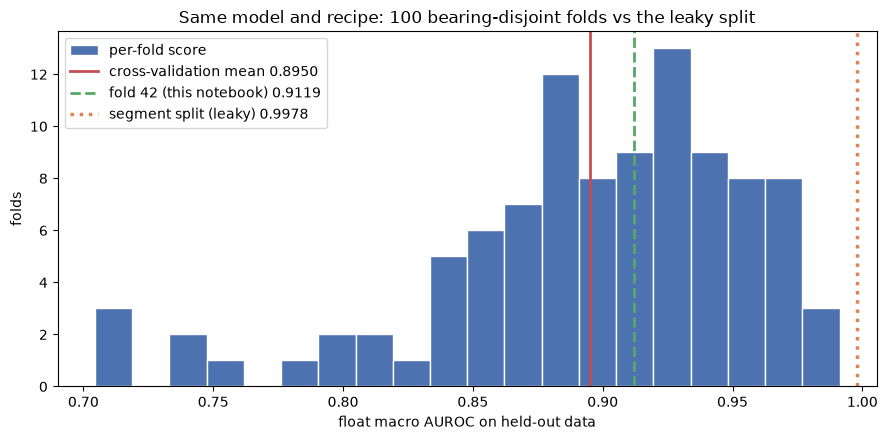

In [15]:
cv = pd.read_csv('docs/cv_results.csv')
per_fold = cv.groupby('fold')['float_auroc'].mean()   # seed-averaged, one value per fold

print(f'Float macro AUROC over {len(per_fold)} bearing-disjoint folds:')
print(f'  mean {per_fold.mean():.4f}   std {per_fold.std(ddof=0):.4f}   '
      f'min {per_fold.min():.4f}   max {per_fold.max():.4f}')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(per_fold, bins=20, color='#4C72B0', edgecolor='white', label='per-fold score')
ax.axvline(per_fold.mean(), color='#C44E52', linewidth=2,
           label=f'cross-validation mean {per_fold.mean():.4f}')
ax.axvline(float_scores['macro'], color='#55A868', linestyle='--', linewidth=2,
           label=f'fold {FOLD} (this notebook) {float_scores["macro"]:.4f}')
ax.axvline(seg_float, color='#DD8452', linestyle=':', linewidth=2.5,
           label=f'segment split (leaky) {seg_float:.4f}')
ax.set_xlabel('float macro AUROC on held-out data')
ax.set_ylabel('folds')
ax.set_title('Same model and recipe: 100 bearing-disjoint folds vs the leaky split')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

### What these numbers mean

Three things stand out in the plot above.

- **The leaky split sits beyond every honest fold.** Same model, same code, same number
  of training windows: the only change is that test windows now come from recordings the
  model has already heard. It is a much easier question, and it is the one most
  published results on these datasets answer.
- **The honest folds spread widely.** With architecture, recipe and seed all fixed,
  the score still moves a long way depending on which bearings are held out. A
  single-fold score cannot tell two architectures apart; only the cross-validation mean
  can.
- **Fold 42 is typical,** which is why it was chosen for the pretrained models and the
  hardware benchmark. That makes it a fair illustration, not a better result.

None of this changes how the model runs on Akida: latency, power and sparsity are
properties of the architecture and its inputs, not of the split.

**Next:** [uored_vafcls_notebook_benchmark.ipynb](uored_vafcls_notebook_benchmark.ipynb)
runs the converted model on an AKD1500 and measures its latency and power.